In [1]:
import yfinance as yf
from fredapi import Fred
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
df=pd.read_csv('merged-stockPricedata.csv')

In [3]:
df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,EMA_20,RSI_14,EMA_12,...,FEDFUNDS,UNRATE,GDP,VIXCLS,TEDRATE,DGS10,T10Y3M,M2SL,INDPRO,UMCSENT
0,2020-02-24,72.362038,73.818112,70.190065,72.138777,222195200,72.362038,72.362038,NaN,72.362038,...,0.842414,3.5,21727.657,25.03,0.15,1.38,-0.15,15871.606897,101.6718,101.0
1,2020-02-25,69.910973,73.417688,69.437753,73.034258,230673600,71.136505,72.128603,0.000000,71.984951,...,0.810345,3.5,21727.657,27.85,0.14,1.33,-0.20,15889.772414,101.6718,101.0
2,2020-02-26,71.020012,72.289226,69.527537,69.534818,198054800,71.097674,72.023023,32.763073,71.836499,...,0.778276,3.5,21727.657,27.56,0.11,1.33,-0.20,15907.937931,101.6718,101.0
3,2020-02-27,66.377571,69.406208,66.241671,68.217082,320605600,69.917648,71.485361,13.227130,70.996664,...,0.746207,3.5,21727.657,39.16,0.16,1.30,-0.15,15926.103448,101.6718,101.0
4,2020-02-28,66.338753,67.564287,62.215637,62.431625,426510000,69.201869,70.995208,13.156488,70.280062,...,0.714138,3.5,21727.657,40.11,0.21,1.13,-0.14,15944.268966,101.6718,101.0


In [4]:
df.isnull().sum()

Date                0
Close               0
High                0
Low                 0
Open                0
Volume              0
SMA_20              0
EMA_20              0
RSI_14              1
EMA_12              0
EMA_26              0
MACD                0
MACD_Signal         0
MACD_Hist           0
Bollinger_Middle    0
Bollinger_Upper     0
Bollinger_Lower     0
ATR_14              0
OBV                 0
CPIAUCSL            0
FEDFUNDS            0
UNRATE              0
GDP                 0
VIXCLS              1
TEDRATE             0
DGS10               0
T10Y3M              0
M2SL                0
INDPRO              0
UMCSENT             0
dtype: int64

In [5]:
# Display rows where any column has null values
df[df.isnull().any(axis=1)]


,Date,Close,High,Low,Open,Volume,SMA_20,EMA_20,RSI_14,EMA_12,...,FEDFUNDS,UNRATE,GDP,VIXCLS,TEDRATE,DGS10,T10Y3M,M2SL,INDPRO,UMCSENT
0,2020-02-24,72.362038,73.818112,70.190065,72.138777,222195200,72.362038,72.362038,NaN,72.362038,...,0.842414,3.5,21727.657,25.03,0.15,1.38,-0.15,15871.606897,101.6718,101.0
1256,2025-02-21,245.550003,248.690002,245.220001,245.949997,53119400,235.958032,238.377795,61.329462,240.208448,...,4.330000,4.0,29700.580,NaN,0.09,4.50,0.10,21533.800000,103.5110,71.7


In [6]:
df.dropna(inplace=True)

In [7]:
df.isnull().sum()

Date                0
Close               0
High                0
Low                 0
Open                0
Volume              0
SMA_20              0
EMA_20              0
RSI_14              0
EMA_12              0
EMA_26              0
MACD                0
MACD_Signal         0
MACD_Hist           0
Bollinger_Middle    0
Bollinger_Upper     0
Bollinger_Lower     0
ATR_14              0
OBV                 0
CPIAUCSL            0
FEDFUNDS            0
UNRATE              0
GDP                 0
VIXCLS              0
TEDRATE             0
DGS10               0
T10Y3M              0
M2SL                0
INDPRO              0
UMCSENT             0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
print(df.describe())

             Close         High          Low         Open        Volume  \
count  1255.000000  1255.000000  1255.000000  1255.000000  1.255000e+03   
mean    156.534381   158.115320   154.771123   156.375732  8.839179e+07   
std      42.097703    42.233283    41.859967    42.029934  5.291646e+07   
min      54.449894    55.452160    51.595990    55.350235  2.323470e+07   
25%     130.036919   131.527403   128.420075   129.874959  5.415195e+07   
50%     154.073456   155.747753   151.672010   153.521798  7.440380e+07   
75%     180.840195   182.162432   179.253717   180.969447  1.033646e+08   
max     258.735504   259.814335   257.347047   257.906429  4.265100e+08   

            SMA_20       EMA_20       RSI_14       EMA_12       EMA_26  ...  \
count  1255.000000  1255.000000  1255.000000  1255.000000  1255.000000  ...   
mean    155.265941   155.283403    54.289054   155.803056   154.891477  ...   
std      41.872962    41.706993    12.341569    41.850687    41.593785  ...   
min     

In [10]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'EMA_20',
       'RSI_14', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist',
       'Bollinger_Middle', 'Bollinger_Upper', 'Bollinger_Lower', 'ATR_14',
       'OBV', 'CPIAUCSL', 'FEDFUNDS', 'UNRATE', 'GDP', 'VIXCLS', 'TEDRATE',
       'DGS10', 'T10Y3M', 'M2SL', 'INDPRO', 'UMCSENT'],
      dtype='object')

In [11]:
df.dtypes

Date                 object
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
SMA_20              float64
EMA_20              float64
RSI_14              float64
EMA_12              float64
EMA_26              float64
MACD                float64
MACD_Signal         float64
MACD_Hist           float64
Bollinger_Middle    float64
Bollinger_Upper     float64
Bollinger_Lower     float64
ATR_14              float64
OBV                   int64
CPIAUCSL            float64
FEDFUNDS            float64
UNRATE              float64
GDP                 float64
VIXCLS              float64
TEDRATE             float64
DGS10               float64
T10Y3M              float64
M2SL                float64
INDPRO              float64
UMCSENT             float64
dtype: object

In [12]:
df['Date']=pd.to_datetime(df['Date'])

In [13]:
df.dtypes

Date                datetime64[ns]
Close                      float64
High                       float64
Low                        float64
Open                       float64
Volume                       int64
SMA_20                     float64
EMA_20                     float64
RSI_14                     float64
EMA_12                     float64
EMA_26                     float64
MACD                       float64
MACD_Signal                float64
MACD_Hist                  float64
Bollinger_Middle           float64
Bollinger_Upper            float64
Bollinger_Lower            float64
ATR_14                     float64
OBV                          int64
CPIAUCSL                   float64
FEDFUNDS                   float64
UNRATE                     float64
GDP                        float64
VIXCLS                     float64
TEDRATE                    float64
DGS10                      float64
T10Y3M                     float64
M2SL                       float64
INDPRO              

In [14]:
df.size

37650

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1255 entries, 1 to 1255
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1255 non-null   datetime64[ns]
 1   Close             1255 non-null   float64       
 2   High              1255 non-null   float64       
 3   Low               1255 non-null   float64       
 4   Open              1255 non-null   float64       
 5   Volume            1255 non-null   int64         
 6   SMA_20            1255 non-null   float64       
 7   EMA_20            1255 non-null   float64       
 8   RSI_14            1255 non-null   float64       
 9   EMA_12            1255 non-null   float64       
 10  EMA_26            1255 non-null   float64       
 11  MACD              1255 non-null   float64       
 12  MACD_Signal       1255 non-null   float64       
 13  MACD_Hist         1255 non-null   float64       
 14  Bollinger_Middle  1255 non-nu

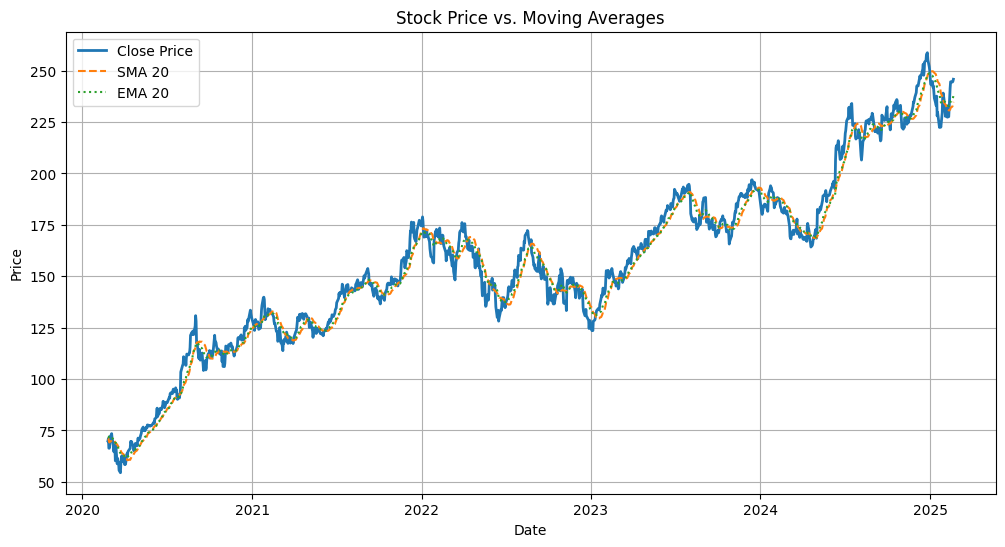

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label="Close Price", linewidth=2)
plt.plot(df['Date'], df['SMA_20'], label="SMA 20", linestyle='dashed')
plt.plot(df['Date'], df['EMA_20'], label="EMA 20", linestyle='dotted')
plt.title("Stock Price vs. Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()


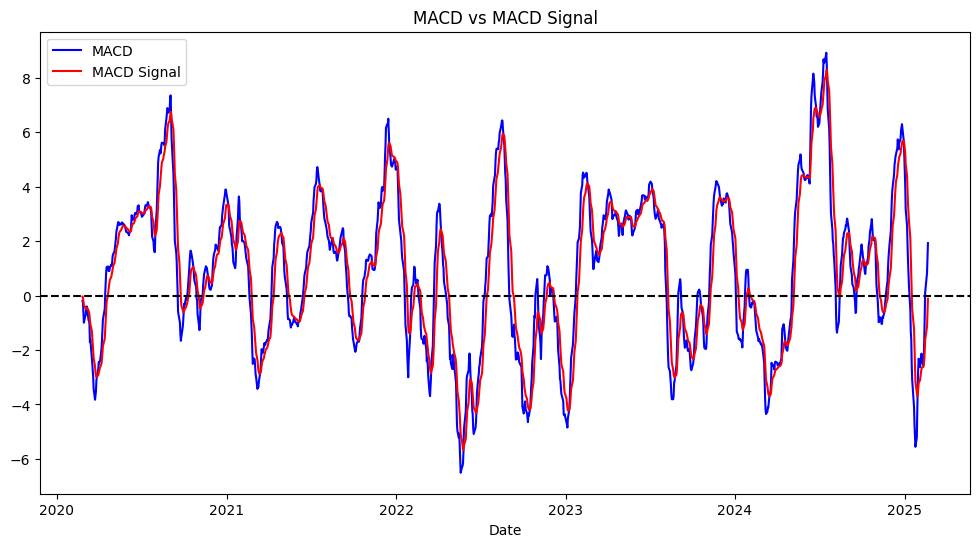

In [17]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['MACD'], label='MACD', color='blue')
plt.plot(df['Date'], df['MACD_Signal'], label='MACD Signal', color='red')
plt.title("MACD vs MACD Signal")
plt.axhline(y=0, color='black', linestyle='dashed')  # Zero line
plt.xlabel("Date")
plt.legend()
plt.show()


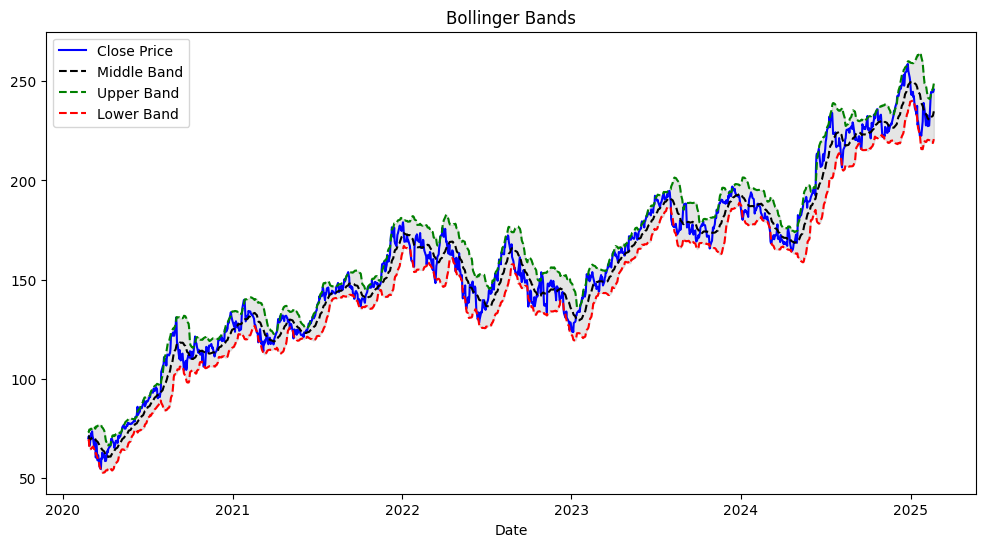

In [18]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')
plt.plot(df['Date'], df['Bollinger_Middle'], label='Middle Band', color='black', linestyle='dashed')
plt.plot(df['Date'], df['Bollinger_Upper'], label='Upper Band', color='green', linestyle='dashed')
plt.plot(df['Date'], df['Bollinger_Lower'], label='Lower Band', color='red', linestyle='dashed')
plt.fill_between(df['Date'], df['Bollinger_Upper'], df['Bollinger_Lower'], color='gray', alpha=0.2)  # Shading
plt.title("Bollinger Bands")
plt.xlabel("Date")
plt.legend()
plt.show()


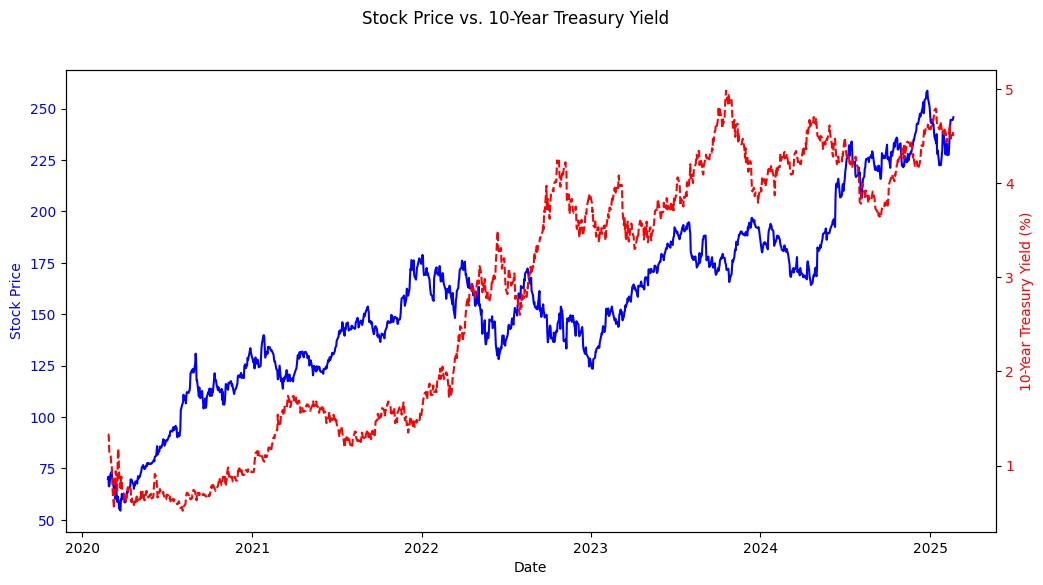

In [19]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Stock price (Left Y-axis)
ax1.set_xlabel("Date")
ax1.set_ylabel("Stock Price", color="blue")
ax1.plot(df["Date"], df["Close"], color="blue", label="Stock Price")
ax1.tick_params(axis='y', labelcolor="blue")

# Interest Rates (Right Y-axis)
ax2 = ax1.twinx()
ax2.set_ylabel("10-Year Treasury Yield (%)", color="red")
ax2.plot(df["Date"], df["DGS10"], color="red", label="10Y Treasury Yield", linestyle="dashed")
ax2.tick_params(axis='y', labelcolor="red")

fig.suptitle("Stock Price vs. 10-Year Treasury Yield")
plt.show()


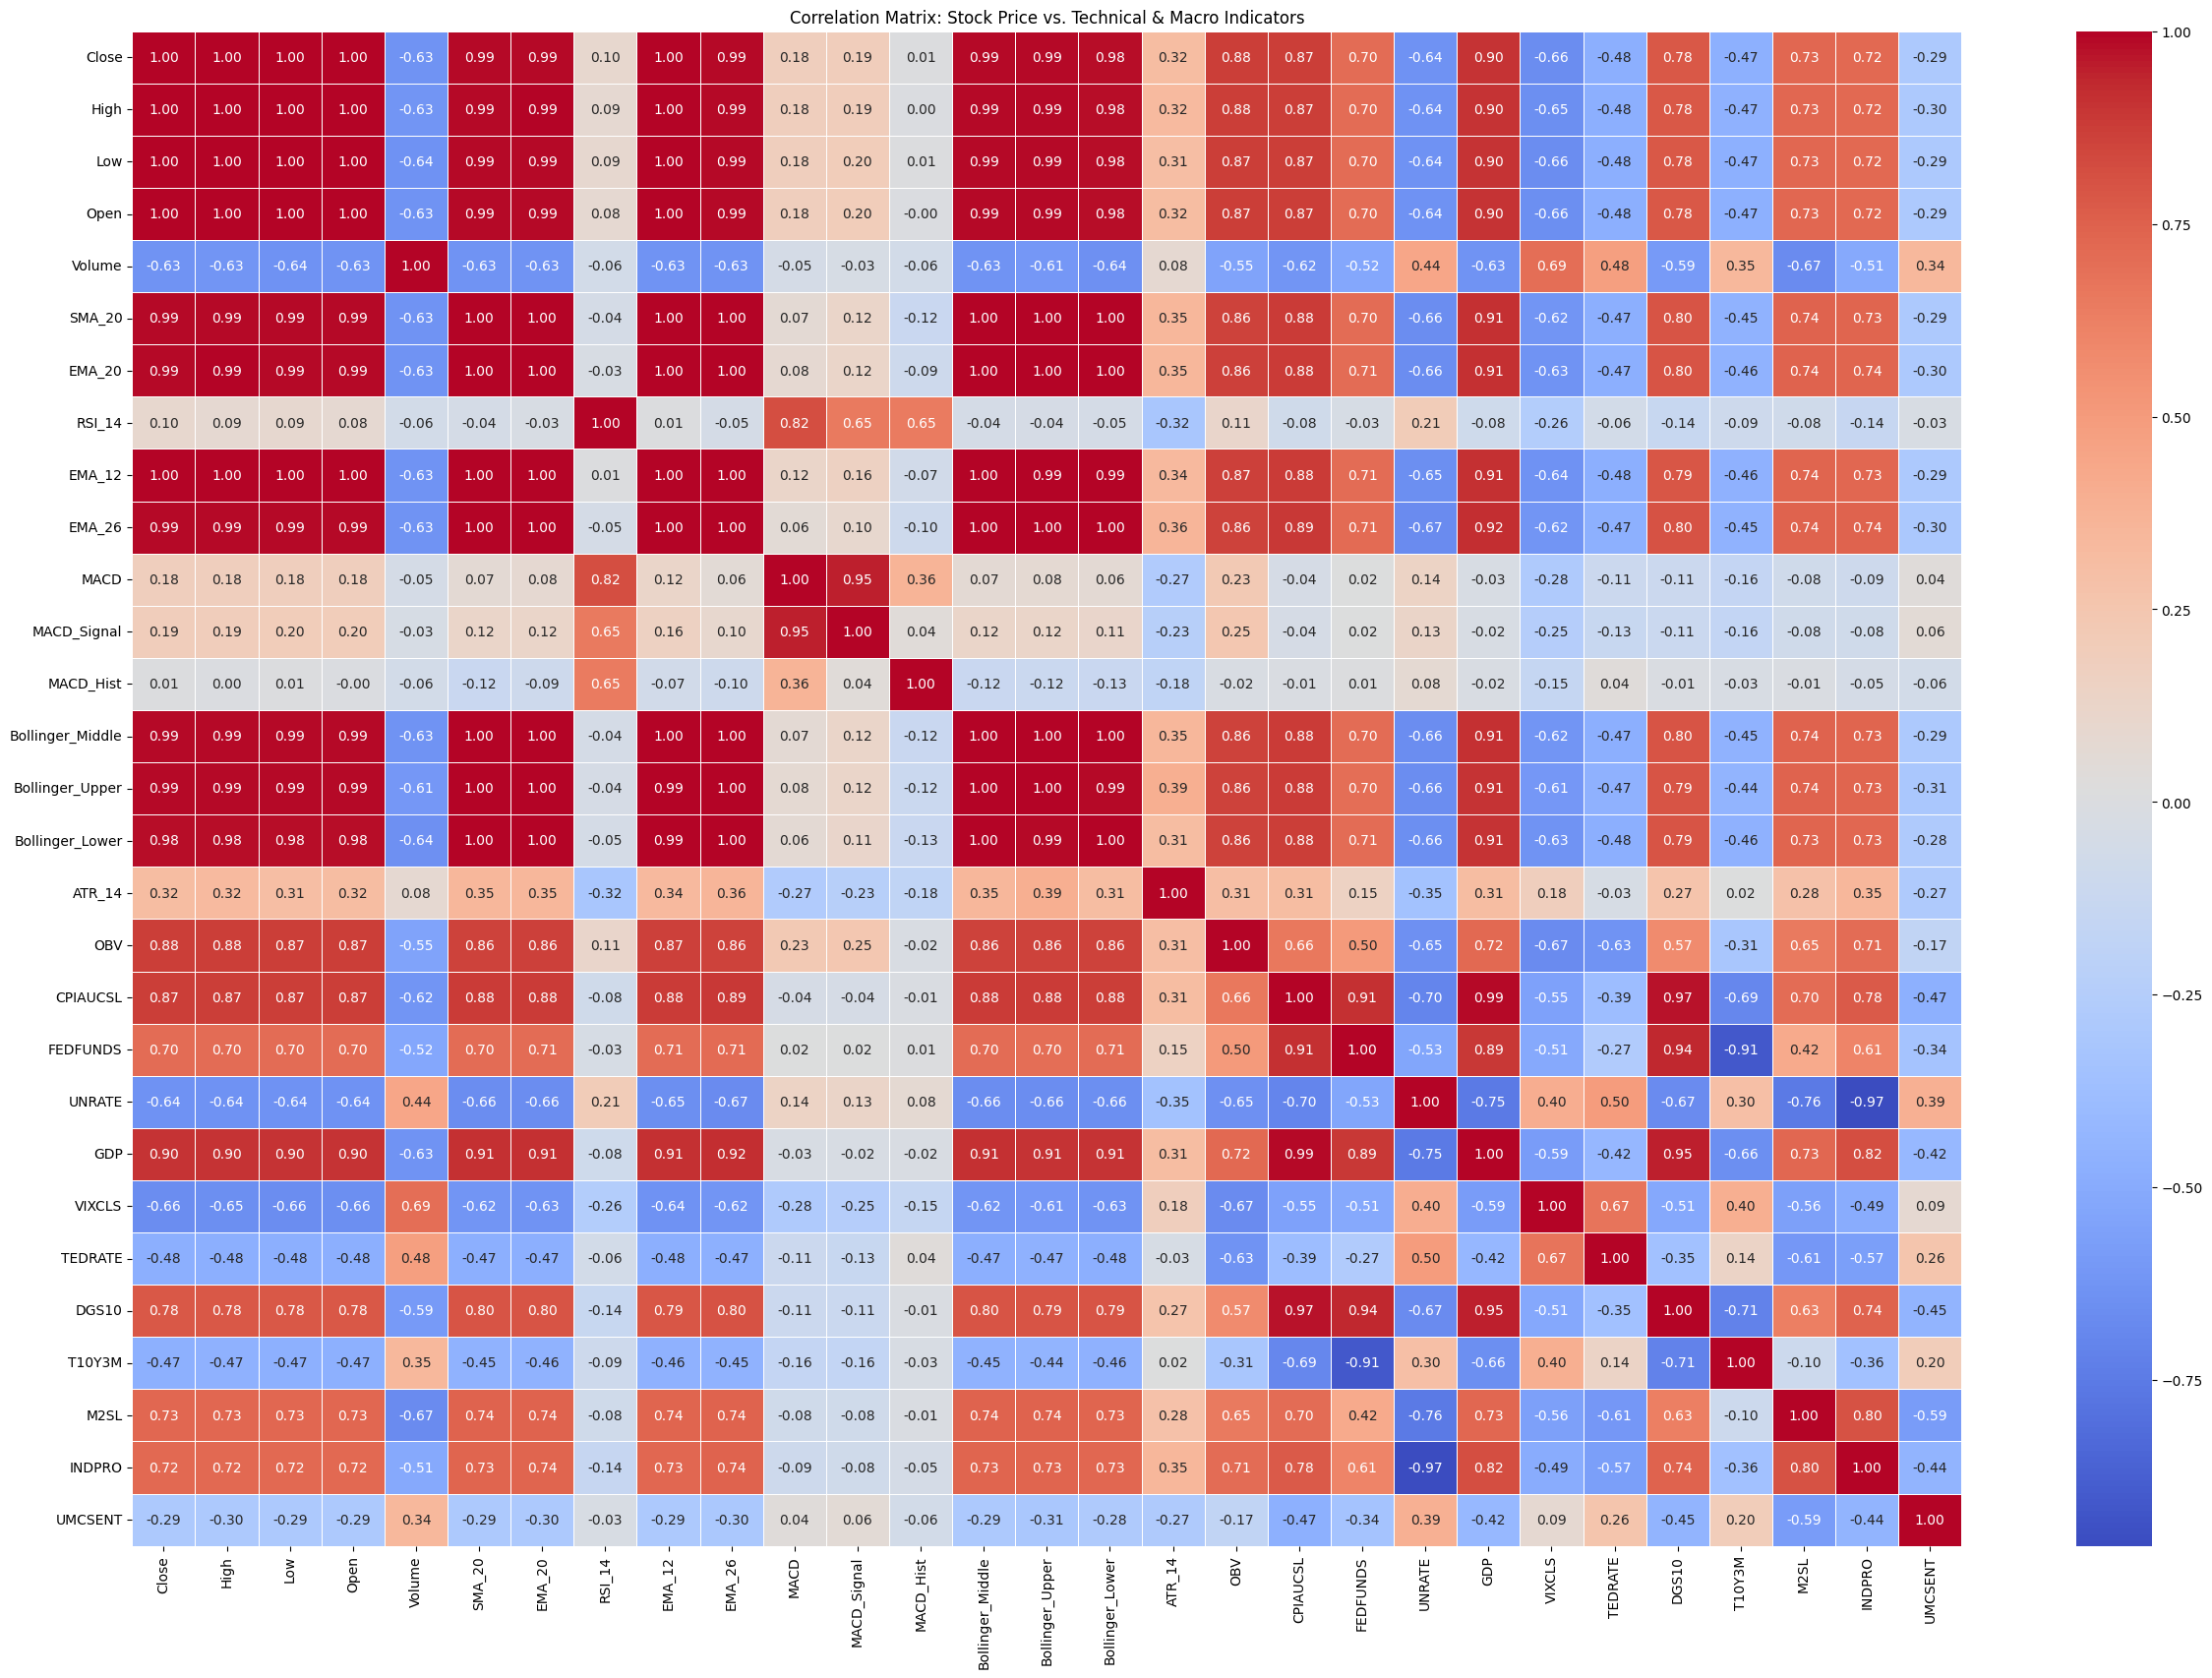

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop the Date column
df_corr = df.drop(columns=['Date'])

# Compute Correlation Matrix
corr_matrix = df_corr.corr()

# Plot Heatmap
plt.figure(figsize=(30,20))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Stock Price vs. Technical & Macro Indicators")
plt.show()


In [21]:
import numpy as np
import pandas as pd

# Compute absolute correlation matrix (ignore signs)
corr_matrix = df.drop(columns=['Date']).corr().abs()

# Create upper triangle matrix to avoid duplicate pairs
upper_triangle = np.triu(np.ones(corr_matrix.shape), k=1)

# Identify feature pairs with |r| > 0.85 (both positive & negative)
high_corr_pairs = (corr_matrix > 0.85) & (upper_triangle == 1)

# List of features to remove
redundant_features = set()

for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if high_corr_pairs.loc[row, col]:  # If correlation is above threshold
            redundant_features.add(col)  # Keep one, remove the other

print("Highly Correlated Features to Remove (|r| > 0.85):", redundant_features)


Highly Correlated Features to Remove (|r| > 0.85): {'SMA_20', 'CPIAUCSL', 'Open', 'T10Y3M', 'EMA_26', 'Bollinger_Middle', 'Low', 'Bollinger_Upper', 'OBV', 'INDPRO', 'GDP', 'EMA_12', 'Bollinger_Lower', 'FEDFUNDS', 'DGS10', 'High', 'EMA_20', 'MACD_Signal'}


In [22]:
# Features to REMOVE due to high correlation (|r| > 0.85)
features_to_remove = [
    'High', 'Low', 'Open', 'Bollinger_Lower', 'Bollinger_Upper', 
    'SMA_20', 'EMA_12', 'EMA_26', 'MACD_Signal', 'FEDFUNDS', 
    'T10Y3M', 'INDPRO'
]

# Features to KEEP
features_to_keep = [
    'Close', 'Bollinger_Middle', 'EMA_20', 'OBV', 'DGS10', 'GDP', 'CPIAUCSL'
]

# Drop the redundant features
df_filtered = df.drop(columns=features_to_remove)

# Print updated dataset shape
print("Final Dataset Shape After Feature Selection:", df_filtered.shape)

# Display remaining columns
print("Remaining Features in Dataset:", df_filtered.columns.tolist())


Final Dataset Shape After Feature Selection: (1255, 18)
Remaining Features in Dataset: ['Date', 'Close', 'Volume', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Hist', 'Bollinger_Middle', 'ATR_14', 'OBV', 'CPIAUCSL', 'UNRATE', 'GDP', 'VIXCLS', 'TEDRATE', 'DGS10', 'M2SL', 'UMCSENT']


Implementing LSTM

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from itertools import product

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load and preprocess data
df_lstm = df_filtered.copy()
if 'Date' in df_lstm.columns:
    df_lstm = df_lstm.drop(columns=['Date'])

# Scale features and target ('Close') separately
feature_cols = df_lstm.columns.difference(['Close'])
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

df_lstm[feature_cols] = scaler_X.fit_transform(df_lstm[feature_cols])
df_lstm['Close'] = scaler_y.fit_transform(df_lstm[['Close']])

# Function to create sequences for multi-output LSTM
def create_multioutput_sequences(data, target_col, input_window, output_window):
    X, y = [], []
    for i in range(len(data) - input_window - output_window + 1):
        X.append(data.iloc[i:i + input_window].values)
        y.append(data[target_col].iloc[i + input_window:i + input_window + output_window].values)
    return np.array(X), np.array(y)

# Define hyperparameter search space
input_windows = [20, 30, 40]  # Different input window sizes
output_window = 10  # Fixed forecast window
lstm_units = [64, 128]  # Number of LSTM neurons
learning_rates = [0.001, 0.0005]  # Learning rate options
batch_sizes = [16, 32]  # Batch sizes

# Store results
best_model = None
best_config = None
best_rmse = float('inf')

# Grid search over hyperparameters
for input_window, lstm_unit, lr, batch_size in product(input_windows, lstm_units, learning_rates, batch_sizes):
    print(f"Training with: input_window={input_window}, lstm_units={lstm_unit}, lr={lr}, batch_size={batch_size}")
    
    X, y = create_multioutput_sequences(df_lstm, 'Close', input_window, output_window)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    X_train = X_train.astype(np.float32)
    X_test = X_test.astype(np.float32)
    y_train = y_train.astype(np.float32)
    y_test = y_test.astype(np.float32)

    # Build model
    model = Sequential([
        LSTM(lstm_unit, activation='relu', input_shape=(input_window, df_lstm.shape[1])),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(output_window)
    ])

    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    # Train model
    model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=batch_size,
        validation_split=0.1,
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Evaluate model
    y_pred_scaled = model.predict(X_test)
    y_pred_actual = scaler_y.inverse_transform(y_pred_scaled)
    y_test_actual = scaler_y.inverse_transform(y_test)
    
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    r2 = r2_score(y_test_actual.flatten(), y_pred_actual.flatten())
    
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")
    
    # Track best model
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model
        best_config = {
            'input_window': input_window,
            'lstm_units': lstm_unit,
            'learning_rate': lr,
            'batch_size': batch_size,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        }

print("\nBest Model Configuration:")
print(best_config)

# Forecast next 10 days using the best model
last_sequence = df_lstm[-best_config['input_window']:].values.reshape(1, best_config['input_window'], df_lstm.shape[1])
forecast_scaled = best_model.predict(last_sequence)
forecast_actual = scaler_y.inverse_transform(forecast_scaled).flatten()

# Generate forecast dates
last_date = pd.to_datetime(df_filtered['Date'].iloc[-1])
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=10)

# Create forecast DataFrame
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecast_Close': forecast_actual
})

print(forecast_df)


2025-03-24 10:44:56.505227: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742831096.520728 1540309 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742831096.525514 1540309 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-24 10:44:56.542147: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Training with: input_window=20, lstm_units=64, lr=0.001, batch_size=16


W0000 00:00:1742831098.762351 1540309 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/ykolla/myenv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 
MAE: 11.52, RMSE: 13.98, R²: 0.7073
Training with: input_window=20, lstm_units=64, lr=0.001, batch_size=32


/home/ykolla/myenv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 
MAE: 10.49, RMSE: 12.93, R²: 0.7478
Training with: input_window=40, lstm_units=128, lr=0.0005, batch_size=16


/home/ykolla/myenv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 
MAE: 9.53, RMSE: 11.66, R²: 0.7949
Training with: input_window=40, lstm_units=128, lr=0.0005, batch_size=32


/home/ykolla/myenv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 
MAE: 11.93, RMSE: 14.32, R²: 0.6904

Best Model Configuration:
{'input_window': 20, 'lstm_units': 128, 'learning_rate': 0.001, 'batch_size': 16, 'MAE': 7.516546726226807, 'RMSE': 9.422204563836079, 'R2': 0.8671325445175171}
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
        Date  Forecast_Close
0 2025-02-21      230.145889
1 2025-02-22      231.673355
2 2025-02-23      234.169662
3 2025-02-24      237.494476
4 2025-02-25      233.126541
5 2025-02-26      236.012604
6 2025-02-27      237.047836
7 2025-02-28      235.992493
8 2025-03-01      227.909821
9 2025-03-02      237.058243


In [24]:
df_filtered.columns

Index(['Date', 'Close', 'Volume', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Hist',
       'Bollinger_Middle', 'ATR_14', 'OBV', 'CPIAUCSL', 'UNRATE', 'GDP',
       'VIXCLS', 'TEDRATE', 'DGS10', 'M2SL', 'UMCSENT'],
      dtype='object')

BUY-SELL-HOLD RECOMMENDATION

In [25]:
print(df_filtered.columns)
# Compute daily percentage change in closing price from historical data
df_lstm['Price_Change_%'] = df_lstm['Close'].pct_change() * 100

# Drop NaN values that occur due to `pct_change()`
df_lstm = df_lstm.dropna()

# Ensure we have valid data before computing mean
if df_lstm['Price_Change_%'].notna().sum() > 0:
    avg_daily_change = df_lstm['Price_Change_%'].abs().mean()

    # Set a failsafe minimum threshold to avoid zero or inf values
    if np.isinf(avg_daily_change) or avg_daily_change == 0:
        avg_daily_change = 1.0  # Use 1% as a fallback if no meaningful price change is found
else:
    avg_daily_change = 1.0  # Fallback if there are no valid price changes

# Set dynamic Buy/Sell thresholds based on historical data
BUY_THRESHOLD = avg_daily_change * 1.5  # Buy if price change > 1.5x average daily change
SELL_THRESHOLD = -BUY_THRESHOLD  # Sell if price change < -1.5x average daily change

print(f"Computed Buy Threshold: +{BUY_THRESHOLD:.2f}% | Sell Threshold: {SELL_THRESHOLD:.2f}%")


# Compute percentage change for forecasted prices
forecast_df['Price_Change_%'] = forecast_df['Forecast_Close'].pct_change() * 100

# Drop NaN (the first row will have NaN because there’s no previous price)
forecast_df = forecast_df.dropna()

# Apply Buy-Sell-Hold logic
def assign_trade_signal(change):
    if change > BUY_THRESHOLD:
        return 1  # Buy
    elif change < SELL_THRESHOLD:
        return -1  # Sell
    else:
        return 0  # Hold

forecast_df['Trade_Signal'] = forecast_df['Price_Change_%'].apply(assign_trade_signal)

# Display updated forecast with trade signals
print(forecast_df[['Date', 'Forecast_Close', 'Price_Change_%', 'Trade_Signal']])
print(df_filtered.columns)

Index(['Date', 'Close', 'Volume', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Hist',
       'Bollinger_Middle', 'ATR_14', 'OBV', 'CPIAUCSL', 'UNRATE', 'GDP',
       'VIXCLS', 'TEDRATE', 'DGS10', 'M2SL', 'UMCSENT'],
      dtype='object')
Computed Buy Threshold: +1.50% | Sell Threshold: -1.50%
        Date  Forecast_Close  Price_Change_%  Trade_Signal
1 2025-02-22      231.673355        0.663698             0
2 2025-02-23      234.169662        1.077509             0
3 2025-02-24      237.494476        1.419830             0
4 2025-02-25      233.126541       -1.839173            -1
5 2025-02-26      236.012604        1.237977             0
6 2025-02-27      237.047836        0.438631             0
7 2025-02-28      235.992493       -0.445205             0
8 2025-03-01      227.909821       -3.424972            -1
9 2025-03-02      237.058243        4.014051             1
Index(['Date', 'Close', 'Volume', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Hist',
       'Bollinger_Middle', 'ATR_14', 'OBV', 'CPIAUCS

Market-Risk and Volatility Prediction


🔹 GARCH Model Summary:
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                Returns   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:                3280.33
Distribution:                  Normal   AIC:                          -6554.66
Method:            Maximum Likelihood   BIC:                          -6539.26
                                        No. Observations:                 1254
Date:                Mon, Mar 24 2025   Df Residuals:                     1254
Time:                        10:54:39   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      9.2467e-06  5.737e-10  

/home/ykolla/myenv/lib/python3.12/site-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003965. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


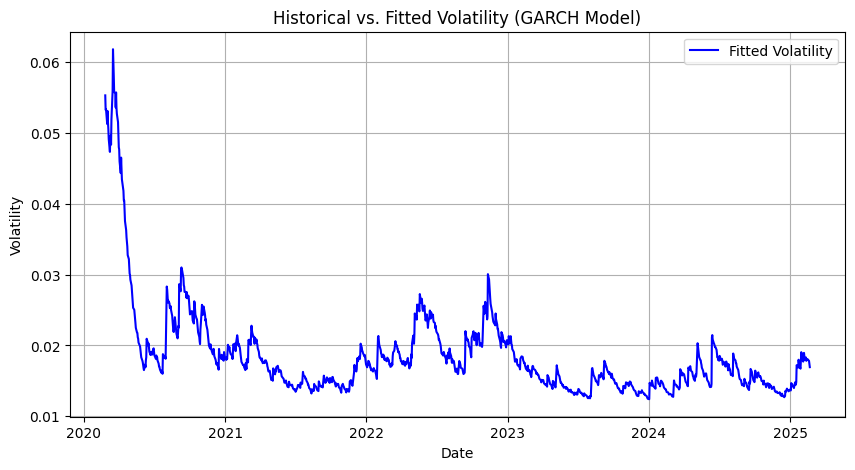

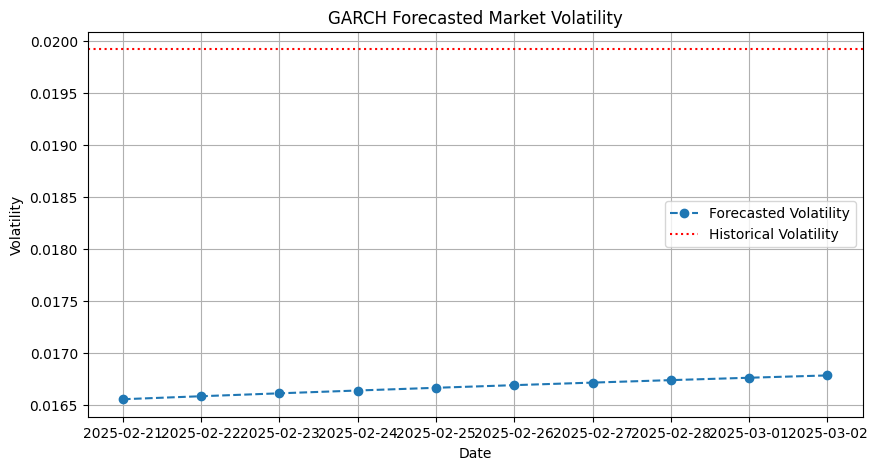


🔹 GARCH-Based Market Risk & Volatility Forecast:
        Date  Forecasted_Volatility
0 2025-02-21               0.016551
1 2025-02-22               0.016580
2 2025-02-23               0.016608
3 2025-02-24               0.016635
4 2025-02-25               0.016661
5 2025-02-26               0.016687
6 2025-02-27               0.016711
7 2025-02-28               0.016735
8 2025-03-01               0.016758
9 2025-03-02               0.016780


In [27]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.preprocessing import StandardScaler

# Step 1: Make a fresh copy for GARCH operations
df_garch = df_filtered.copy()

# Step 2: Ensure 'Date' is datetime and set as index (if needed)
if 'Date' in df_garch.columns:
    df_garch['Date'] = pd.to_datetime(df_garch['Date'], errors='coerce')
    df_garch = df_garch.dropna(subset=['Date'])  # Remove rows where date is NaT
    df_garch.set_index('Date', inplace=True)

# Step 3: Drop 'Date' column just to be sure (optional)
df_garch = df_garch.drop(columns=['Date'], errors='ignore')

# Step 4: Ensure all values are numeric
df_garch = df_garch.apply(pd.to_numeric, errors='coerce')

#  Step 5: Compute Log Returns (GARCH input)
df_garch['Returns'] = np.log(df_garch['Close'] / df_garch['Close'].shift(1))
df_garch = df_garch.dropna()

# Step 6: Scale only non-GARCH features
scaler = StandardScaler()
scaled_features = df_garch.drop(columns=['Close', 'Returns'])
df_scaled = pd.DataFrame(scaler.fit_transform(scaled_features),
                         columns=scaled_features.columns,
                         index=df_garch.index)

# Step 7: Add back unscaled Close and Returns
df_scaled['Close'] = df_garch['Close']
df_scaled['Returns'] = df_garch['Returns']

#Step 8: Fit GARCH(1,1)
garch_model = arch_model(df_scaled['Returns'], vol='Garch', p=1, q=1, mean='Zero', dist='normal')
garch_fit = garch_model.fit(disp='off')

#Step 9: Display GARCH Summary
print("\nGARCH Model Summary:")
print(garch_fit.summary())

#Step 10: Plot Historical vs. Fitted Volatility
plt.figure(figsize=(10, 5))
plt.plot(df_garch.index, garch_fit.conditional_volatility, label="Fitted Volatility", color='blue')
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("Historical vs. Fitted Volatility (GARCH Model)")
plt.legend()
plt.grid()
plt.show()

#Step 11: Forecast Volatility for Next 10 Days
garch_forecast = garch_fit.forecast(horizon=10)

#Step 12: Generate Forecast Dates
# forecast_start_date = df_filtered.index[-1]  # 👈 FIXED: get last datetime index
# forecast_dates = pd.date_range(start=forecast_start_date + pd.Timedelta(days=1), periods=10)

# Extract last valid date (whether 'Date' is column or index)
if 'Date' in df_filtered.columns:
    last_date = pd.to_datetime(df_filtered['Date'].iloc[-1])
else:
    last_date = df_filtered.index[-1]

# Generate 10-day forecast horizon
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=10)



#Step 13: Create Forecast DataFrame
df_volatility_forecast = pd.DataFrame({
    'Date': forecast_dates,
    'Forecasted_Volatility': np.sqrt(garch_forecast.variance.values[-1])  # Last row = current forecast
})

# Step 14: Plot Forecasted Volatility
plt.figure(figsize=(10, 5))
plt.plot(df_volatility_forecast['Date'], df_volatility_forecast['Forecasted_Volatility'],
         marker='o', linestyle='dashed', label='Forecasted Volatility')
plt.axhline(y=df_garch['Returns'].std(), color='r', linestyle='dotted', label="Historical Volatility")
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.title('GARCH Forecasted Market Volatility')
plt.legend()
plt.grid()
plt.show()

#Step 15: Print Forecast Table
print("\n GARCH-Based Market Risk & Volatility Forecast:")
print(df_volatility_forecast)
